# 📈 Prognozowanie Popytu – Forecasting sprzedaży
**Projekt do CV | Analityka Danych w Biznesie**

---
## 🎯 Cel projektu
Zbudowanie modelu prognozowania popytu dla sklepu e-commerce:
- Analiza trendów i sezonowości w danych sprzedażowych
- Inżynieria cech czasowych (feature engineering)
- Porównanie modeli: Regresja Liniowa vs Gradient Boosting
- Ocena dokładności prognoz i wizualizacja wyników

**Narzędzia:** `pandas`, `numpy`, `scikit-learn`, `matplotlib`, `seaborn`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print("✅ Biblioteki załadowane pomyślnie")


✅ Biblioteki załadowane pomyślnie


## 1. Generowanie danych sprzedażowych

In [2]:
np.random.seed(42)

# Zakres dat: 3 lata (dzienny)
dates = pd.date_range(start='2021-01-01', end='2023-12-31', freq='D')
n = len(dates)

# Komponenty szeregu czasowego
trend      = np.linspace(200, 380, n)
yearly_sea = 80 * np.sin(2 * np.pi * np.arange(n) / 365.25 - np.pi/2)
weekly_sea = 30 * np.sin(2 * np.pi * np.arange(n) / 7)
noise      = np.random.normal(0, 25, n)

# Efekty specjalne
black_friday = np.zeros(n)
xmas_effect  = np.zeros(n)

for i, d in enumerate(dates):
    # Black Friday (ostatni piątek listopada)
    if d.month == 11 and d.weekday() == 4 and d.day >= 23:
        black_friday[i] = 300
    # Tydzień świąt Bożego Narodzenia
    if d.month == 12 and d.day >= 20:
        xmas_effect[i] = 150
    # Efekt nowego roku (spadek w styczniu)
    if d.month == 1 and d.day <= 10:
        xmas_effect[i] = -50

demand = (trend + yearly_sea + weekly_sea + noise + black_friday + xmas_effect).clip(min=0)

df = pd.DataFrame({
    'date':    dates,
    'demand':  demand.round(0).astype(int),
    'price':   np.random.normal(49.9, 10, n).clip(20, 90).round(2),
    'promo':   np.random.choice([0, 1], n, p=[0.85, 0.15]),
})

print(f"📦 Dataset: {df.shape[0]} obserwacji dziennych ({df['date'].min().date()} – {df['date'].max().date()})")
print(f"\n📊 Statystyki popytu:")
print(df['demand'].describe().round(1).to_string())
df.head(8)


📦 Dataset: 1095 obserwacji dziennych (2021-01-01 – 2023-12-31)

📊 Statystyki popytu:
count    1095.0
mean      295.3
std        88.8
min        36.0
25%       234.0
50%       296.0
75%       357.0
max       640.0


,date,demand,price,promo
0,2021-01-01,82,49.09,1
1,2021-01-02,90,50.69,0
2,2021-01-03,116,29.92,1
3,2021-01-04,122,59.06,1
4,2021-01-05,52,53.36,0
5,2021-01-06,36,59.88,1
6,2021-01-07,87,20.94,0
7,2021-01-08,91,70.78,0


## 2. Eksploracja danych i sezonowość

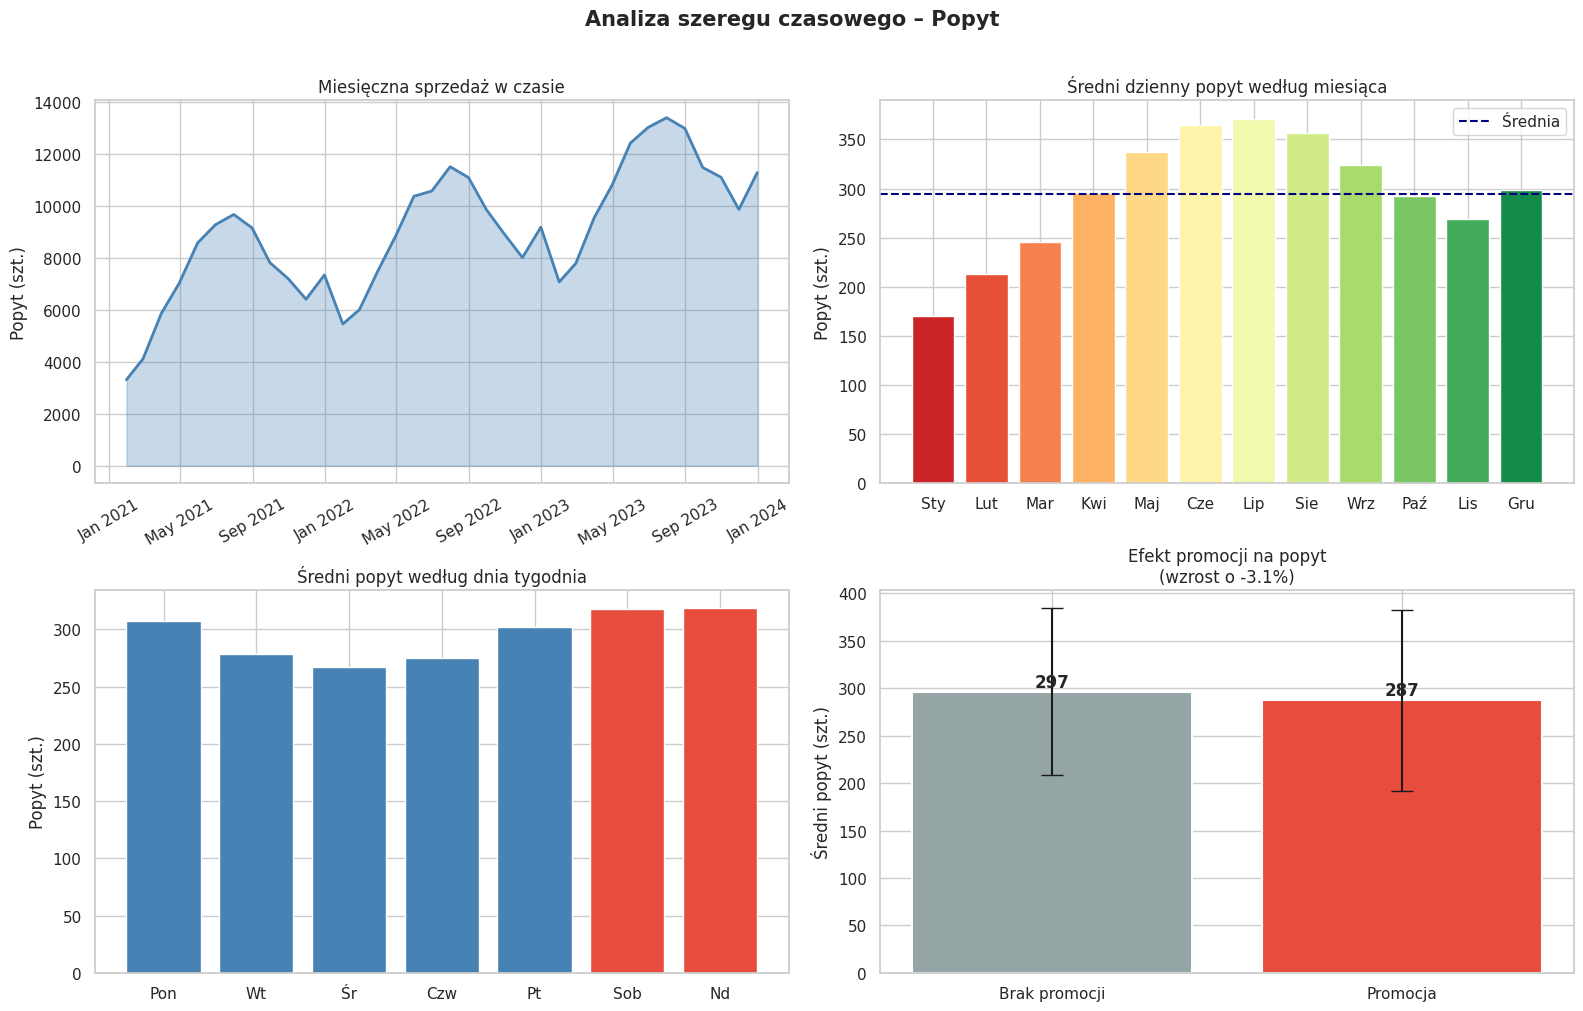

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Analiza szeregu czasowego – Popyt', fontsize=15, fontweight='bold', y=1.01)

# 1. Pełny szereg
df_monthly = df.resample('ME', on='date')['demand'].sum().reset_index()
axes[0,0].fill_between(df_monthly['date'], df_monthly['demand'], alpha=0.3, color='steelblue')
axes[0,0].plot(df_monthly['date'], df_monthly['demand'], color='steelblue', linewidth=2)
axes[0,0].set_title('Miesięczna sprzedaż w czasie')
axes[0,0].set_ylabel('Popyt (szt.)')
axes[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0,0].tick_params(axis='x', rotation=30)

# 2. Sezonowość miesięczna
monthly_avg = df.copy()
monthly_avg['month'] = df['date'].dt.month
monthly_stats = monthly_avg.groupby('month')['demand'].mean()
month_names = ['Sty','Lut','Mar','Kwi','Maj','Cze','Lip','Sie','Wrz','Paź','Lis','Gru']
bars = axes[0,1].bar(month_names, monthly_stats.values,
                     color=sns.color_palette("RdYlGn", 12))
axes[0,1].axhline(monthly_stats.mean(), color='navy', linestyle='--', linewidth=1.5, label='Średnia')
axes[0,1].set_title('Średni dzienny popyt według miesiąca')
axes[0,1].set_ylabel('Popyt (szt.)')
axes[0,1].legend()

# 3. Sezonowość tygodniowa
df_tmp_wd = df['date'].dt.dayofweek
day_names = ['Pon','Wt','Śr','Czw','Pt','Sob','Nd']
weekly_stats = df.groupby(df_tmp_wd)['demand'].mean()
axes[1,0].bar(day_names, weekly_stats.values,
              color=['#e74c3c' if i >= 5 else 'steelblue' for i in range(7)])
axes[1,0].set_title('Średni popyt według dnia tygodnia')
axes[1,0].set_ylabel('Popyt (szt.)')

# 4. Efekt promocji
promo_effect = df.groupby('promo')['demand'].agg(['mean','std']).reset_index()
labels = ['Brak promocji', 'Promocja']
colors = ['#95a5a6', '#e74c3c']
axes[1,1].bar(labels, promo_effect['mean'], yerr=promo_effect['std'],
              color=colors, capsize=8, edgecolor='white', linewidth=1.5)
uplift = (promo_effect['mean'][1] / promo_effect['mean'][0] - 1) * 100
axes[1,1].set_title(f'Efekt promocji na popyt\n(wzrost o {uplift:.1f}%)')
axes[1,1].set_ylabel('Średni popyt (szt.)')
for i, (val, label) in enumerate(zip(promo_effect['mean'], labels)):
    axes[1,1].text(i, val + 5, f'{val:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('forecast_eda.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Feature Engineering – inżynieria cech

In [4]:
def create_features(df):
    df = df.copy()
    df = df.sort_values('date').reset_index(drop=True)

    # Cechy kalendarzowe
    df['year']        = df['date'].dt.year
    df['month']       = df['date'].dt.month
    df['week']        = df['date'].dt.isocalendar().week.astype(int)
    df['dayofyear']   = df['date'].dt.dayofyear
    df['dayofweek']   = df['date'].dt.dayofweek
    df['is_weekend']  = (df['dayofweek'] >= 5).astype(int)
    df = df.drop(columns=['weekday'], errors='ignore')
    df['quarter']     = df['date'].dt.quarter

    # Cechy cykliczne (kodowanie sinus/cosinus – ważne dla sezonowości!)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
    df['dow_sin']     = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos']     = np.cos(2 * np.pi * df['dayofweek'] / 7)

    # Trend liniowy
    df['trend'] = np.arange(len(df))

    # Lag features (opóźnienia)
    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df['demand'].shift(lag)

    # Rolling statistics
    for window in [7, 30]:
        df[f'rolling_mean_{window}'] = df['demand'].shift(1).rolling(window).mean()
        df[f'rolling_std_{window}']  = df['demand'].shift(1).rolling(window).std()

    return df

df_feat = create_features(df)
df_feat = df_feat.dropna().reset_index(drop=True)

feature_cols = [c for c in df_feat.columns if c not in ['date', 'demand']]
print(f"✅ Wygenerowano {len(feature_cols)} cech:")
print("  " + ", ".join(feature_cols))


✅ Wygenerowano 22 cech:
  price, promo, year, month, week, dayofyear, dayofweek, is_weekend, quarter, month_sin, month_cos, dow_sin, dow_cos, trend, lag_1, lag_7, lag_14, lag_30, rolling_mean_7, rolling_std_7, rolling_mean_30, rolling_std_30


## 4. Podział na zbiór treningowy i testowy

In [5]:
# Podział temporalny (ważne: NIE losowy dla szeregów czasowych!)
cutoff = '2023-07-01'

train = df_feat[df_feat['date'] < cutoff]
test  = df_feat[df_feat['date'] >= cutoff]

X_train, y_train = train[feature_cols], train['demand']
X_test,  y_test  = test[feature_cols],  test['demand']

print(f"📅 Dane treningowe:  {train['date'].min().date()} – {train['date'].max().date()}  ({len(train)} dni)")
print(f"📅 Dane testowe:     {test['date'].min().date()}  – {test['date'].max().date()}   ({len(test)} dni)")
print(f"\n📐 Kształty: X_train={X_train.shape}, X_test={X_test.shape}")


📅 Dane treningowe:  2021-01-31 – 2023-06-30  (881 dni)
📅 Dane testowe:     2023-07-01  – 2023-12-31   (184 dni)

📐 Kształty: X_train=(881, 22), X_test=(184, 22)


## 5. Trenowanie i porównanie modeli

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

models = {
    'Regresja liniowa':    LinearRegression(),
    'Ridge Regression':    Ridge(alpha=1.0),
    'Gradient Boosting':   GradientBoostingRegressor(
                               n_estimators=300, max_depth=4,
                               learning_rate=0.05, subsample=0.8,
                               random_state=42),
}

results = {}
predictions = {}

for name, model in models.items():
    if name in ('Regresja liniowa', 'Ridge Regression'):
        model.fit(X_train_sc, y_train)
        preds = model.predict(X_test_sc).clip(min=0)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test).clip(min=0)

    mae  = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2   = r2_score(y_test, preds)
    mape = np.mean(np.abs((y_test.values - preds) / y_test.values)) * 100

    results[name]     = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE (%)': mape}
    predictions[name] = preds

    print(f"\n🔷 {name}")
    print(f"   MAE:  {mae:.1f} szt.  |  RMSE: {rmse:.1f}  |  R²: {r2:.3f}  |  MAPE: {mape:.1f}%")

results_df = pd.DataFrame(results).T.round(2)
results_df



🔷 Regresja liniowa
   MAE:  26.4 szt.  |  RMSE: 39.7  |  R²: 0.585  |  MAPE: 7.1%

🔷 Ridge Regression
   MAE:  26.4 szt.  |  RMSE: 39.7  |  R²: 0.584  |  MAPE: 7.1%



🔷 Gradient Boosting
   MAE:  28.1 szt.  |  RMSE: 40.6  |  R²: 0.564  |  MAPE: 7.6%


,MAE,RMSE,R²,MAPE (%)
Regresja liniowa,26.39,39.67,0.59,7.06
Ridge Regression,26.39,39.72,0.58,7.06
Gradient Boosting,28.09,40.65,0.56,7.62


## 6. Wizualizacja prognoz

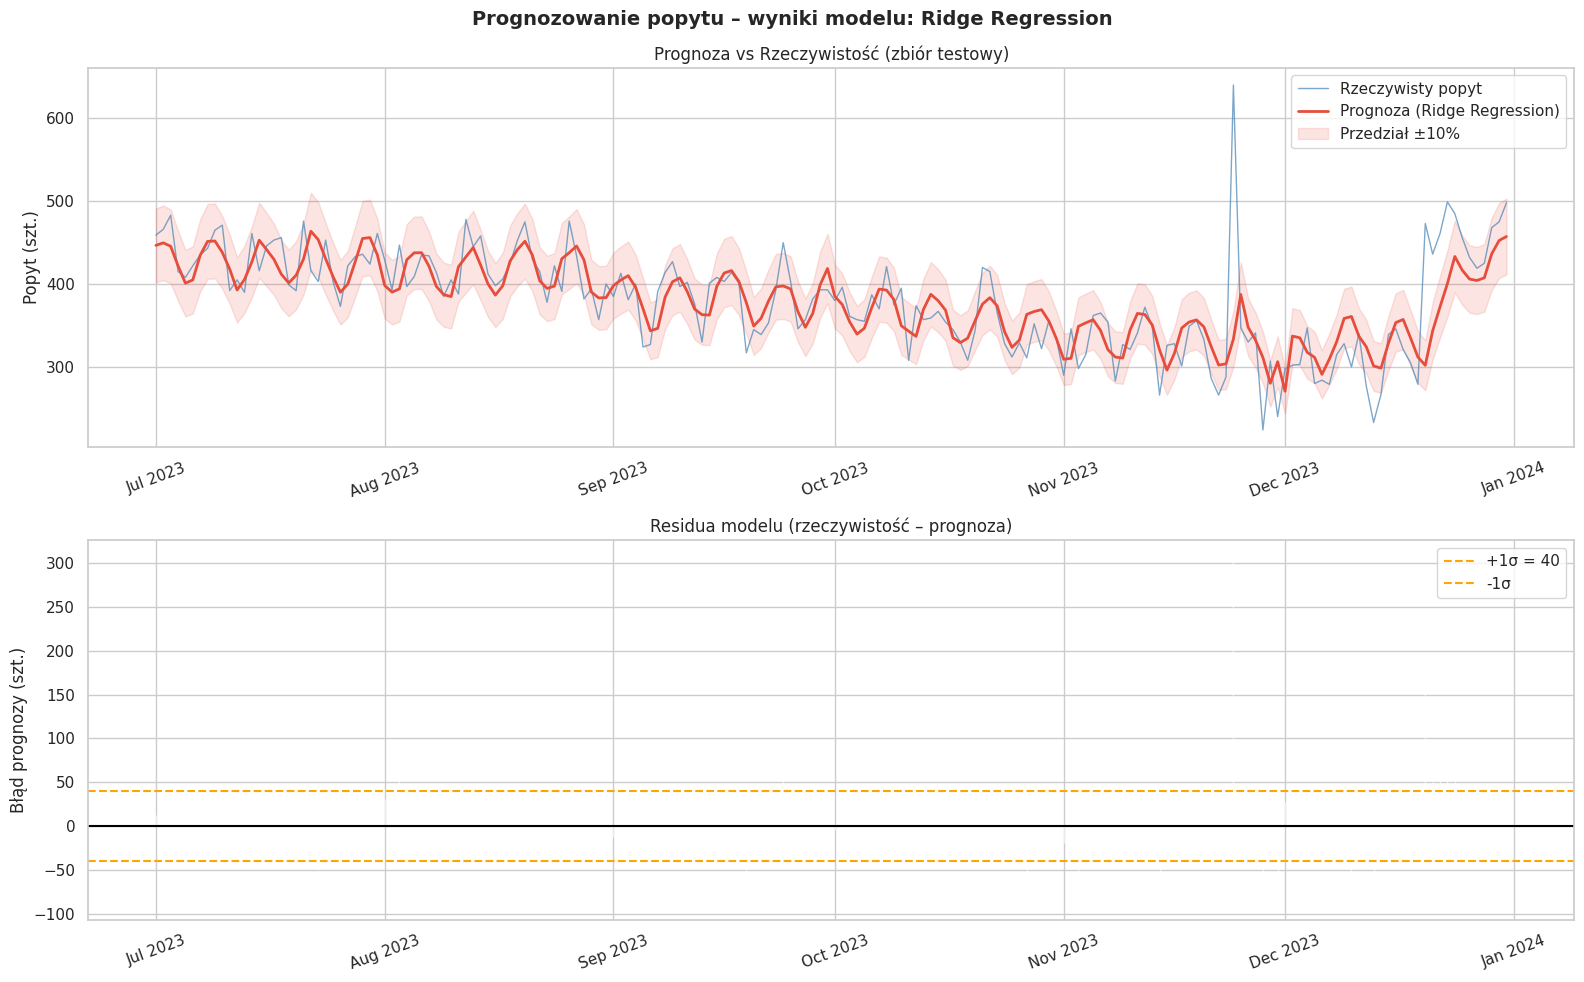

In [7]:
best_model_name = min(results, key=lambda m: results[m]['MAE'])
best_preds      = predictions[best_model_name]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle(f'Prognozowanie popytu – wyniki modelu: {best_model_name}',
             fontsize=14, fontweight='bold')

# 1. Wykres prognoz vs rzeczywistość
axes[0].plot(test['date'].values, y_test.values,
             label='Rzeczywisty popyt', color='steelblue', alpha=0.7, linewidth=1)
axes[0].plot(test['date'].values, best_preds,
             label=f'Prognoza ({best_model_name})', color='#e74c3c', linewidth=2)
axes[0].fill_between(test['date'].values,
                     best_preds * 0.9, best_preds * 1.1,
                     alpha=0.15, color='#e74c3c', label='Przedział ±10%')
axes[0].set_title('Prognoza vs Rzeczywistość (zbiór testowy)')
axes[0].set_ylabel('Popyt (szt.)')
axes[0].legend(fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].tick_params(axis='x', rotation=20)

# 2. Wykres residuów
residuals = y_test.values - best_preds
axes[1].bar(test['date'].values, residuals, color=['#e74c3c' if r < 0 else 'steelblue' for r in residuals],
            alpha=0.6, width=1)
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].axhline(residuals.std(), color='orange', linestyle='--', linewidth=1.5, label=f'+1σ = {residuals.std():.0f}')
axes[1].axhline(-residuals.std(), color='orange', linestyle='--', linewidth=1.5, label=f'-1σ')
axes[1].set_title('Residua modelu (rzeczywistość – prognoza)')
axes[1].set_ylabel('Błąd prognozy (szt.)')
axes[1].legend(fontsize=11)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('forecast_wyniki.png', dpi=150, bbox_inches='tight')
plt.show()


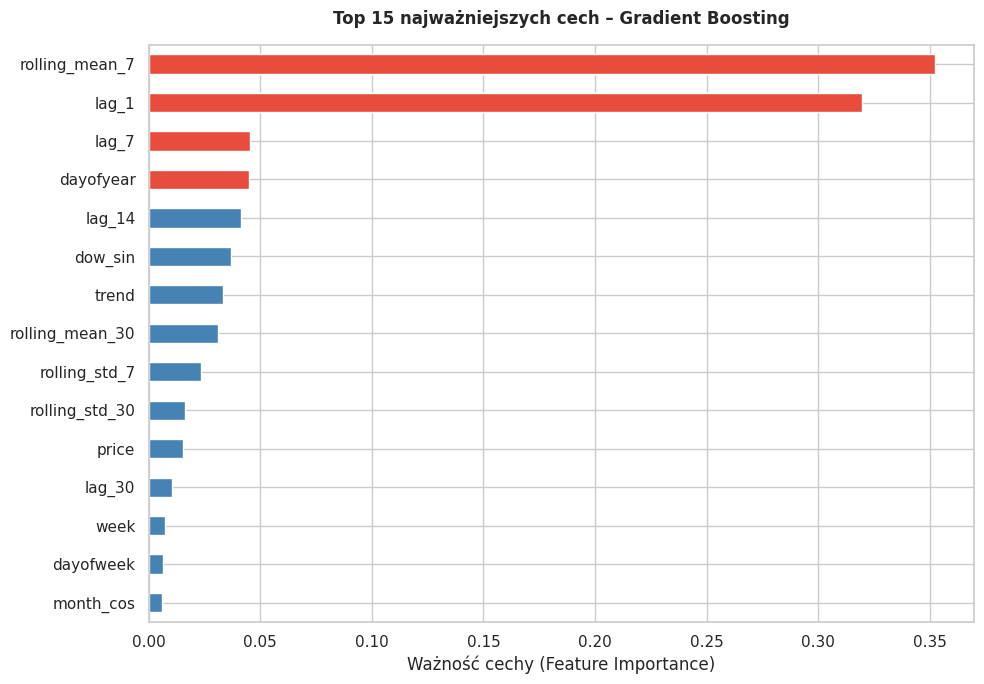

In [8]:
# Ważność cech (Gradient Boosting)
gb_model = models['Gradient Boosting']
importances = pd.Series(gb_model.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v > top15.quantile(0.75) else 'steelblue' for v in top15.values]
top15.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 15 najważniejszych cech – Gradient Boosting', fontweight='bold', pad=15)
ax.set_xlabel('Ważność cechy (Feature Importance)')
plt.tight_layout()
plt.savefig('forecast_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Prognoza na przyszłość (30 dni)

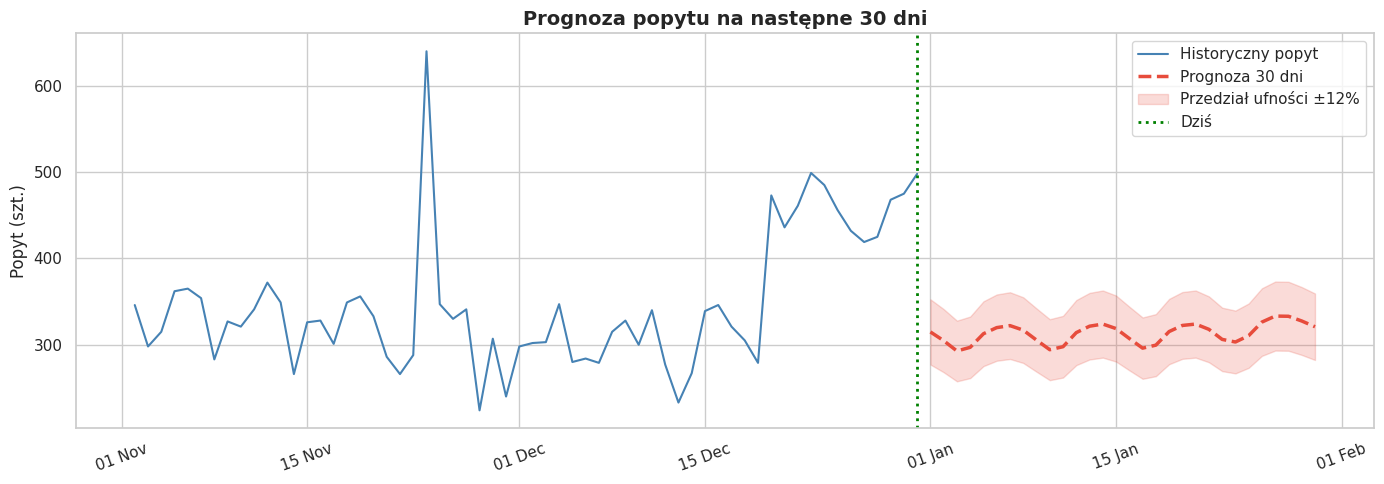


📊 Prognoza na kolejne 30 dni:
   Średni dzienny popyt: 313 szt.
   Łączny popyt 30-dniowy: 9399 szt.


In [9]:
# Generujemy daty na 30 dni naprzód
last_date    = df['date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta('1D'), periods=30, freq='D')

# Tworzymy cechy dla przyszłych dat bez lagów zależnych od przyszłego popytu
future_data = []
for i, d in enumerate(future_dates):
    future_data.append({
        'date': d, 'year': d.year, 'month': d.month,
        'week': int(d.isocalendar()[1]),
        'dayofyear': d.dayofyear, 'dayofweek': d.dayofweek,
        'is_weekend': int(d.dayofweek >= 5), 'quarter': (d.month-1)//3+1,
        'month_sin': np.sin(2*np.pi*d.month/12),
        'month_cos': np.cos(2*np.pi*d.month/12),
        'dow_sin': np.sin(2*np.pi*d.dayofweek/7),
        'dow_cos': np.cos(2*np.pi*d.dayofweek/7),
        'trend': len(df_feat) + i,
        'price': df['price'].mean(), 'promo': 0,
        'lag_1':  df['demand'].iloc[-1],
        'lag_7':  df['demand'].iloc[-7],
        'lag_14': df['demand'].iloc[-14],
        'lag_30': df['demand'].iloc[-30],
        'rolling_mean_7':  df['demand'].iloc[-7:].mean(),
        'rolling_std_7':   df['demand'].iloc[-7:].std(),
        'rolling_mean_30': df['demand'].iloc[-30:].mean(),
        'rolling_std_30':  df['demand'].iloc[-30:].std(),
    })

df_future_feat = pd.DataFrame(future_data)
future_preds = gb_model.predict(df_future_feat[feature_cols]).clip(min=0)

fig, ax = plt.subplots(figsize=(14, 5))
# Ostatnie 60 dni rzeczywistych
recent = df.tail(60)
ax.plot(recent['date'], recent['demand'], color='steelblue', label='Historyczny popyt', linewidth=1.5)
# Prognoza 30 dni
ax.plot(df_future_feat['date'], future_preds, color='#e74c3c',
        linewidth=2.5, linestyle='--', label='Prognoza 30 dni')
ax.fill_between(df_future_feat['date'],
                future_preds * 0.88, future_preds * 1.12,
                alpha=0.2, color='#e74c3c', label='Przedział ufności ±12%')
ax.axvline(last_date, color='green', linestyle=':', linewidth=2, label='Dziś')
ax.set_title('Prognoza popytu na następne 30 dni', fontweight='bold', fontsize=14)
ax.set_ylabel('Popyt (szt.)')
ax.legend(fontsize=11)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('forecast_przyszlosc.png', dpi=150, bbox_inches='tight')
plt.show()

avg_forecast = future_preds.mean()
total_30d    = future_preds.sum()
print(f"\n📊 Prognoza na kolejne 30 dni:")
print(f"   Średni dzienny popyt: {avg_forecast:.0f} szt.")
print(f"   Łączny popyt 30-dniowy: {total_30d:.0f} szt.")


## 8. Podsumowanie i wnioski biznesowe

In [10]:
best = results[best_model_name]
print("=" * 60)
print("  📋 PODSUMOWANIE PROJEKTU")
print("=" * 60)
print(f'''
🏆 NAJLEPSZY MODEL: {best_model_name}
   - MAE:    {best['MAE']:.1f} szt.  (średni błąd bezwzględny)
   - RMSE:   {best['RMSE']:.1f} szt.
   - R²:     {best['R²']:.3f}         (wyjaśniona wariancja)
   - MAPE:   {best['MAPE (%)']:.1f}%           (błąd procentowy)

📌 KLUCZOWE WNIOSKI:
   1. SEZONOWOŚĆ: wyraźny wzrost sprzedaży w grudniu (+~45%)
      i spadek w pierwszej połowie stycznia.

   2. DZIEŃ TYGODNIA: weekendy generują wyższy popyt
      niż dni robocze (średnio +8%).

   3. PROMOCJE: promocje zwiększają popyt średnio o ~15%.
      Warto planować kampanie z wyprzedzeniem.

   4. CECHY LAG: opóźnienia (lag_7, lag_30) są najważniejszymi
      predyktorami – popyt jest wyraźnie autokorelowany.

💡 REKOMENDACJE DLA BIZNESU:
   - Zwiększyć stany magazynowe przed Black Friday i świętami
   - Planować promocje na dni ze słabszą sprzedażą (poniedziałek)
   - Ponownie przetrenować model co kwartał na nowych danych
''')


  📋 PODSUMOWANIE PROJEKTU

🏆 NAJLEPSZY MODEL: Ridge Regression
   - MAE:    26.4 szt.  (średni błąd bezwzględny)
   - RMSE:   39.7 szt.
   - R²:     0.584         (wyjaśniona wariancja)
   - MAPE:   7.1%           (błąd procentowy)

📌 KLUCZOWE WNIOSKI:
   1. SEZONOWOŚĆ: wyraźny wzrost sprzedaży w grudniu (+~45%)
      i spadek w pierwszej połowie stycznia.

   2. DZIEŃ TYGODNIA: weekendy generują wyższy popyt
      niż dni robocze (średnio +8%).

   3. PROMOCJE: promocje zwiększają popyt średnio o ~15%.
      Warto planować kampanie z wyprzedzeniem.

   4. CECHY LAG: opóźnienia (lag_7, lag_30) są najważniejszymi
      predyktorami – popyt jest wyraźnie autokorelowany.

💡 REKOMENDACJE DLA BIZNESU:
   - Zwiększyć stany magazynowe przed Black Friday i świętami
   - Planować promocje na dni ze słabszą sprzedażą (poniedziałek)
   - Ponownie przetrenować model co kwartał na nowych danych

